In [9]:
import tensorflow as tf
import keras
import numpy as np
import sys
sys.path.append("../")

In [ ]:
DATA_DIR = "../mu3e_trigger_data"
SIGNAL_PIXEL_FILE = f"{DATA_DIR}/run42_sig_pixel_128.npy"
BACKGROUND_PIXEL_FILE = f"{DATA_DIR}/run42_bg_pixel_128.npy"
SIGNAL_DATA_FILE = f"{DATA_DIR}/run42_sig_mppc_128.npy"
BACKGROUND_DATA_FILE = f"{DATA_DIR}/run42_bg_mppc_128.npy"

bg_pixel_spacetime = np.load(BACKGROUND_PIXEL_FILE)
sig_pixel_spacetime = np.load(SIGNAL_PIXEL_FILE)
bg_mppc_spacetime = np.load(BACKGROUND_DATA_FILE)
sig_mppc_spacetime = np.load(SIGNAL_DATA_FILE)

# Normalize spacetime data
from src.utils import normalize_data



input_seq_len = bg_pixel_spacetime.shape[1]
input_dim = bg_pixel_spacetime.shape[2] - 1  # Exclude timestamp

In [11]:
from src.model.components import SelfAttentionStack, PoolingAttentionBlock, GenerateMask, MLP, point_transformer

In [ ]:
position_input = keras.layers.Input(shape=(input_seq_len, input_dim), name="position_input")
time_input = keras.layers.Input(shape=(input_seq_len, 1), name="time_input")

feature_dim = 8
num_seeds = 16
latent_dim = num_seeds
mask = GenerateMask()(time_input)
input_embedding = point_transformer(
    name="point_transformer",
)(time_input, position_input, mask=mask)
attention_block = SelfAttentionStack(
    num_heads=4,
    key_dim=feature_dim,
    name="self_attention_stack",
)(input_embedding, mask=mask)
attention_pooling = PoolingAttentionBlock(
    num_heads=4,
    num_seeds = 1,
    key_dim=feature_dim,
    name="pooling_attention_block",
)(attention_block, mask=mask)
latent_output = keras.layers.Flatten()(attention_pooling)
output_layer = MLP(
    output_dim=1,
    num_layers=4,
    activation="sigmoid",
    name="output_layer",
)(latent_output)
model = keras.Model(inputs=[position_input, time_input], outputs=output_layer)
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss="binary_crossentropy", metrics=["accuracy"])

In [13]:
model.summary()

Model: "functional_9"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ time_input          │ (None, 128, 1)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ position_input      │ (None, 128, 3)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ generate_mask_1     │ (None, 128, 1)    │          0 │ time_input[0][0]  │
│ (GenerateMask)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ point_transformer   │ (None, 128, 8)    │        484 │ time_input[0][0], │
│ (point_transformer) │                   │            │ position_input[0… │
│                     │                   │            │ generate_mask_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ self_attention_sta… │ (None, 128, 8)    │      4,320 │ point_transforme… │
│ (SelfAttentionStac… │                   │            │ generate_mask_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pooling_attention_… │ (None, 1, 8)      │      1,448 │ self_attention_s… │
│ (PoolingAttentionB… │                   │            │ generate_mask_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten_1 (Flatten) │ (None, 8)         │          0 │ pooling_attentio… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ output_layer (MLP)  │ (None, 1)         │        102 │ flatten_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 6,447 (25.18 KB)

 Trainable params: 6,447 (25.18 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
X_position = np.concatenate((bg_pixel_spacetime[:, :, :-1], sig_pixel_spacetime[:, :, :-1]), axis=0)
X_time = np.concatenate((bg_pixel_spacetime[:, :, -1:], sig_pixel_spacetime[:, :, -1:]), axis=0)
y = np.concatenate((np.zeros(bg_pixel_spacetime.shape[0]), np.ones(sig_pixel_spacetime.shape[0])), axis=0)


In [15]:
from sklearn.model_selection import train_test_split
X_train_position, X_test_position, X_train_time, X_test_time, y_train, y_test = train_test_split(
    X_position, X_time, y, test_size=0.2, random_state=42
)

In [16]:
model.fit(
    x=[X_train_position, X_train_time],
    y=y_train,
    validation_split = 0.2,
    epochs=10,
    batch_size=512,
    callbacks=[
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)],
)

Epoch 1/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 394s 2s/step - accuracy: 0.5554 - loss: 0.6881 - val_accuracy: 0.5775 - val_loss: 0.6803
Epoch 2/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 386s 2s/step - accuracy: 0.5780 - loss: 0.6779 - val_accuracy: 0.5935 - val_loss: 0.6675
Epoch 3/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 335s 2s/step - accuracy: 0.5939 - loss: 0.6665 - val_accuracy: 0.6064 - val_loss: 0.6598
Epoch 4/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 375s 2s/step - accuracy: 0.5993 - loss: 0.6609 - val_accuracy: 0.6106 - val_loss: 0.6552
Epoch 5/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 390s 2s/step - accuracy: 0.6102 - loss: 0.6539 - val_accuracy: 0.6124 - val_loss: 0.6537
Epoch 6/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 364s 2s/step - accuracy: 0.6109 - loss: 0.6509 - val_accuracy: 0.6163 - val_loss: 0.6501
Epoch 7/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 403s 2s/step - accuracy: 0.6140 - loss: 0.6489 - val_accuracy: 0.6164 - val_loss: 0.6486
Epoch 8/10
174/174 ━━━━━━━━━━━━━━━━━━━━ 431s 2s/step - accuracy: 0.6163 - loss: 0.6472 - val_accu

In [17]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
predictions = model.predict([X_test_position, X_test_time])
seq_length = (X_test_position != -1).all(axis=-1).sum(axis=-1)

868/868 ━━━━━━━━━━━━━━━━━━━━ 83s 95ms/step


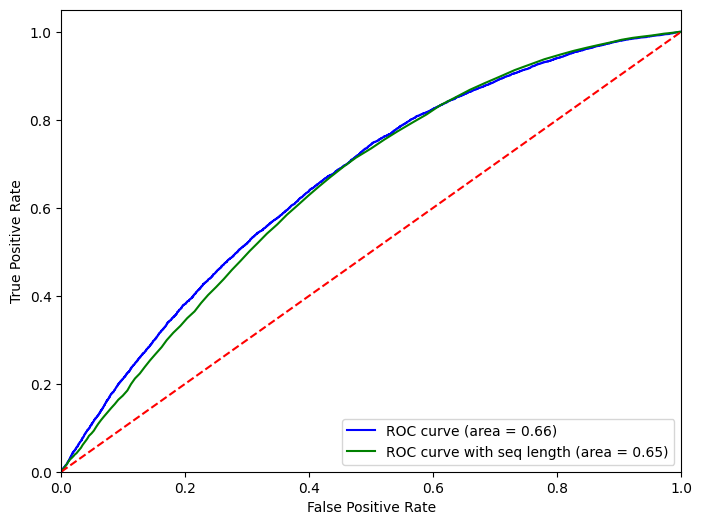

In [18]:
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(y_test, predictions)
fpr_seq_length, tpr_seq_length, thresholds_seq_length = roc_curve(y_test, seq_length)
roc_auc_seq_length = auc(fpr_seq_length, tpr_seq_length)
roc_auc = auc(fpr, tpr)
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label='ROC curve (area = {:.2f})'.format(roc_auc))
plt.plot(fpr_seq_length, tpr_seq_length, color='green', label='ROC curve with seq length (area = {:.2f})'.format(roc_auc_seq_length))
plt.plot([0, 1], [0, 1], color='red', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc='lower right')

In [19]:
np.corrcoef(predictions.flatten(), seq_length)

array([[1.        , 0.71765397],
       [0.71765397, 1.        ]])

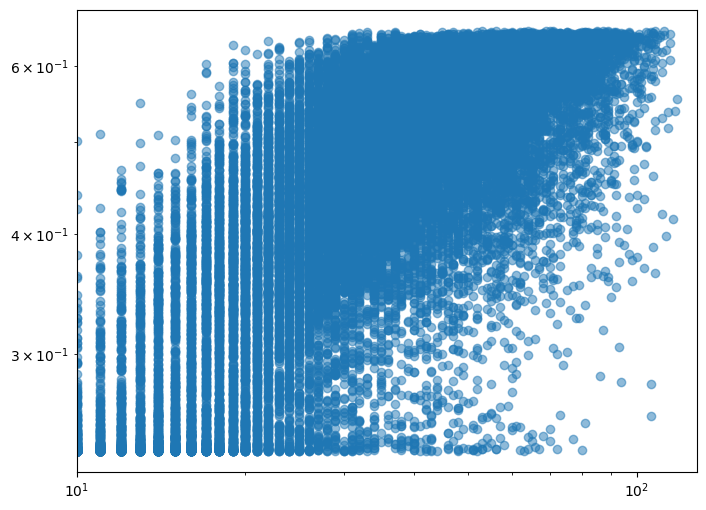

In [ ]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(seq_length,predictions.flatten(), alpha=0.5)
ax.set_xlim([10, 128])